In [20]:
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import tight_layout
%matplotlib inline

In [21]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [22]:
conn = sqlite3.connect('oscars.db')

In [23]:
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,stg_oscars
1,ceremony
2,film
3,category
4,sqlite_sequence
5,nominee
6,nomination
7,participation
8,dim_ceremony
9,dim_category


In [26]:
#Gráfico 1 — Q3: Top 10 filmes mais nomeados (horizontal bar chart)

q3 = pd.read_sql_query("""
    SELECT df.title, COUNT(*) AS nominations
    FROM fact_nomination fn
    JOIN dim_film df ON fn.film_key = df.film_key
    WHERE df.title IS NOT NULL
    GROUP BY df.title
    ORDER BY nominations DESC
    LIMIT 10;
""", conn)

q3

,title,nominations
0,A Star Is Born,26
1,West Side Story,18
2,Titanic,16
3,Mutiny on the Bounty,15
4,Moulin Rouge,15
5,Gone with the Wind,15
6,Little Women,14
7,La La Land,14
8,Cleopatra,14
9,All about Eve,14


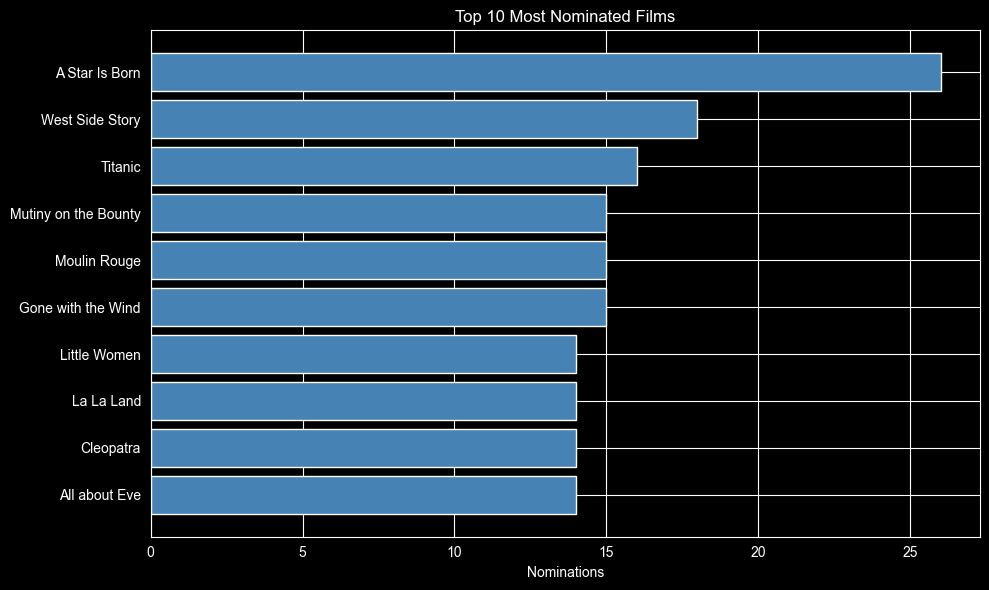

In [29]:
fig, ax = plt.subplots(figsize=(10,6))

ax.barh(q3['title'], q3['nominations'],color='steelblue') #desenha barras horizontais

ax.set_xlabel('Nominations')
ax.set_title('Top 10 Most Nominated Films')
ax.invert_yaxis()   #o filme com mais nomiações fica no topo (ordem decrescente)

plt.tight_layout()
plt.show()
